# CyberShield

## Hyperparameter Tuning and Model Optimization


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import joblib
import os
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data = pd.read_csv("../output/engineered_dataset.csv")
print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (145222, 17)


,ackdat,synack,dload,tcprtt,dmean,rate,sbytes,dbytes,smean,dinpkt,dur,sload,sinpkt,djit,sjit,label,attack_cat
0,-0.682211,-0.599759,-0.367413,-0.692397,-0.537041,-0.242915,-0.061763,-0.129779,-0.528779,-0.096566,-0.237501,-0.183584,-0.089948,-0.178936,-0.136807,0,6
1,-0.682211,-0.599759,-0.208811,-0.692397,2.924532,-0.242862,-0.059690,0.089099,-0.493230,-0.090415,-0.138246,-0.183615,-0.083601,0.120559,-0.136103,0,6
2,0.244910,0.339636,-0.350616,0.322327,2.006222,-0.243648,-0.061301,-0.061702,-0.516930,-0.014325,0.044557,-0.183651,-0.038524,2.304421,0.249938,0,6
3,-0.682211,-0.599759,-0.369059,-0.692397,-0.468656,-0.243655,-0.060151,-0.126651,-0.493230,-0.025221,0.055547,-0.183645,-0.058094,0.905024,-0.131645,0,6
4,0.369810,0.487734,-0.368857,0.471810,-0.530528,-0.243413,-0.060561,-0.129277,-0.489280,-0.037925,-0.175897,-0.183614,-0.084137,-0.156304,-0.083007,0,6


## Prepare Detection Dataset

In [3]:
X = data.drop(["label", "attack_cat"], axis=1)

y = data["label"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nTarget Distribution:")
print(y.value_counts())

Features Shape: (145222, 15)
Target Shape: (145222,)

Target Distribution:
label
0    79965
1    65257
Name: count, dtype: int64


## Split Dataset for Tuning

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (116177, 15)
Testing Data: (29045, 15)


## Define Hyperparameter Search Space

In [5]:
param_grid = {
    "learning_rate": [0.05, 0.1, 0.2],
    "max_iter": [100, 150, 200],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [20, 30, 50],
    "l2_regularization": [0, 0.1, 1]
}

print("Hyperparameter Search Space Created")

Hyperparameter Search Space Created


## Hyperparameter Optimization

In [6]:
hgb_model = HistGradientBoostingClassifier(
    random_state=42
)

hgb_search = RandomizedSearchCV(
    estimator=hgb_model,
    param_distributions=param_grid,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

hgb_search.fit(X_train, y_train)

print("Best Parameters:")
print(hgb_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'max_iter': 200, 'learning_rate': 0.05, 'l2_regularization': 0}


## Evaluate Tuned Detection Model

In [7]:
best_hgb = hgb_search.best_estimator_
tuned_prediction = best_hgb.predict(X_test)
tuned_accuracy = accuracy_score(
    y_test,
    tuned_prediction
)
tuned_precision = precision_score(
    y_test,
    tuned_prediction,
    zero_division=0
)
tuned_recall = recall_score(
    y_test,
    tuned_prediction,
    zero_division=0
)
tuned_f1 = f1_score(
    y_test,
    tuned_prediction,
    zero_division=0
)
print("Tuned HistGradientBoosting")
print("--------------------------")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)

Tuned HistGradientBoosting
--------------------------
Accuracy : 0.8989154759855397
Precision: 0.8815630657815329
Recall   : 0.895341710082746
F1 Score : 0.8883989660939638


## Compare Before and After Tuning

In [8]:
comparison = pd.DataFrame({
    "Version": [
        "Before Tuning",
        "After Tuning"
    ],
    "Accuracy": [
        0.897091,
        tuned_accuracy
    ],
    "Precision": [
        0.876863,
        tuned_precision
    ],
    "Recall": [
        0.896951,
        tuned_recall
    ],
    "F1 Score": [
        0.886793,
        tuned_f1
    ]
})

comparison

,Version,Accuracy,Precision,Recall,F1 Score
0,Before Tuning,0.897091,0.876863,0.896951,0.886793
1,After Tuning,0.898915,0.881563,0.895342,0.888399


## Tuned Model Confusion Matrix

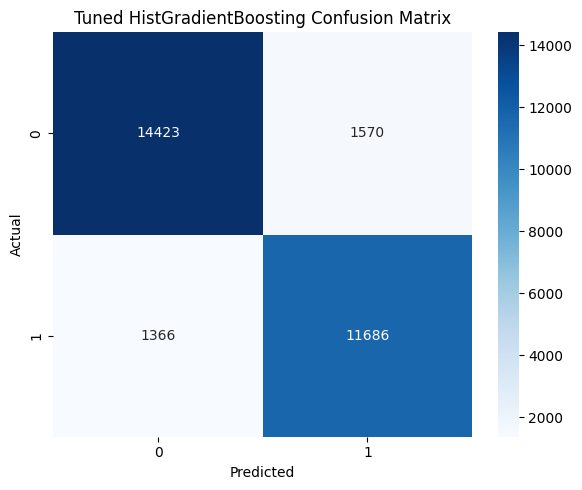

In [9]:
cm = confusion_matrix(
    y_test,
    tuned_prediction
)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Tuned HistGradientBoosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## False Negative Analysis

In [10]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    tuned_prediction
).ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

print("\nFalse Negative Rate:", fn / (fn + tp))

True Negatives : 14423
False Positives: 1570
False Negatives: 1366
True Positives  : 11686

False Negative Rate: 0.10465828991725407


## Detection Threshold Optimization

In [11]:
attack_probabilities = best_hgb.predict_proba(X_test)[:, 1]
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]
threshold_results = []
for threshold in thresholds:
    threshold_prediction = (
        attack_probabilities >= threshold
    ).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        threshold_prediction
    ).ravel()
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            threshold_prediction
        ),
        "Precision": precision_score(
            y_test,
            threshold_prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            threshold_prediction,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            threshold_prediction,
            zero_division=0
        ),
        "False Negatives": fn,
        "False Positives": fp
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,Threshold,Accuracy,Precision,Recall,F1 Score,False Negatives,False Positives
0,0.30,0.880083,0.803489,0.970503,0.879134,385,3098
1,0.35,0.889206,0.824127,0.957861,0.885975,550,2668
2,0.40,0.896092,0.844858,0.941695,0.890652,761,2257
3,0.45,0.898984,0.865958,0.917177,0.890832,1081,1853
4,0.50,0.898915,0.881563,0.895342,0.888399,1366,1570


## Select Protection-Oriented Detection Threshold

In [12]:
best_threshold_row = threshold_results_df.sort_values(
    by=["Recall", "F1 Score"],
    ascending=False
).iloc[0]

protection_threshold = best_threshold_row["Threshold"]

print("Selected Protection Threshold:", protection_threshold)
print("Recall:", best_threshold_row["Recall"])
print("F1 Score:", best_threshold_row["F1 Score"])
print("False Negatives:", best_threshold_row["False Negatives"])

Selected Protection Threshold: 0.3
Recall: 0.9705026049647564
F1 Score: 0.8791338446056147
False Negatives: 385.0


## Compare Default and Protection-Oriented Threshold

In [13]:
default_prediction = (
    attack_probabilities >= 0.50
).astype(int)

protection_prediction = (
    attack_probabilities >= protection_threshold
).astype(int)

default_cm = confusion_matrix(
    y_test,
    default_prediction
)

protection_cm = confusion_matrix(
    y_test,
    protection_prediction
)

default_tn, default_fp, default_fn, default_tp = default_cm.ravel()

protection_tn, protection_fp, protection_fn, protection_tp = protection_cm.ravel()

print("Default Threshold (0.50)")
print("------------------------")
print("False Negatives:", default_fn)
print("False Positives:", default_fp)
print("Recall:", recall_score(
    y_test,
    default_prediction,
    zero_division=0
))

print("\nProtection Threshold")
print("--------------------")
print("Threshold:", protection_threshold)
print("False Negatives:", protection_fn)
print("False Positives:", protection_fp)
print("Recall:", recall_score(
    y_test,
    protection_prediction,
    zero_division=0
))

Default Threshold (0.50)
------------------------
False Negatives: 1366
False Positives: 1570
Recall: 0.895341710082746

Protection Threshold
--------------------
Threshold: 0.3
False Negatives: 385
False Positives: 3098
Recall: 0.9705026049647564


## Protection-Oriented Threshold Visualization

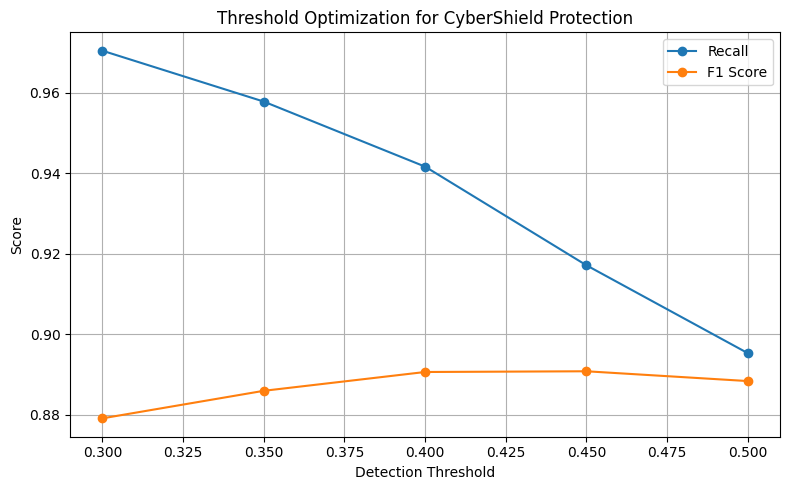

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Detection Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization for CyberShield Protection")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Save Optimized Detection Model

In [15]:
final_detection_model = best_hgb
final_detection_threshold = protection_threshold

os.makedirs("../models", exist_ok=True)

joblib.dump(
    final_detection_model,
    "../models/cybershield_tuned_detection_model.pkl"
)

joblib.dump(
    final_detection_threshold,
    "../models/protection_threshold.pkl"
)

print("Optimized detection model saved successfully.")
print("Protection threshold saved successfully.")
print("Final threshold:", final_detection_threshold)

Optimized detection model saved successfully.
Protection threshold saved successfully.
Final threshold: 0.3


## Attack Classification Hyperparameter Tuning

In [16]:

attack_data = data[data["label"] == 1].copy()

print("Attack Dataset Shape:", attack_data.shape)
print("\nAttack Category Distribution:")
print(attack_data["attack_cat"].value_counts())

Attack Dataset Shape: (65257, 17)

Attack Category Distribution:
attack_cat
3    26749
4    18313
7     8012
2     4873
5     3057
0     1442
1     1389
8     1257
9      165
Name: count, dtype: int64


## Prepare Attack Classification Data

In [17]:
X_attack = attack_data.drop(
    ["label", "attack_cat"],
    axis=1
)

y_attack = attack_data["attack_cat"]

print("Attack Features Shape:", X_attack.shape)
print("Attack Target Shape:", y_attack.shape)

Attack Features Shape: (65257, 15)
Attack Target Shape: (65257,)


## Split Attack Classification Dataset

In [18]:
X_attack_train, X_attack_test, y_attack_train, y_attack_test = train_test_split(
    X_attack,
    y_attack,
    test_size=0.20,
    random_state=42,
    stratify=y_attack
)

print("Attack Training Data:", X_attack_train.shape)
print("Attack Testing Data:", X_attack_test.shape)

Attack Training Data: (52205, 15)
Attack Testing Data: (13052, 15)


## Define Attack Classification Model

In [19]:
from sklearn.ensemble import RandomForestClassifier

attack_rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

print("Random Forest classifier created.")

Random Forest classifier created.


## Define Classification Hyperparameter Search Space

In [20]:
attack_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

print("Attack Classification Search Space Created")

Attack Classification Search Space Created


## Optimize Attack Classification Model

In [21]:
attack_search = RandomizedSearchCV(
    estimator=attack_rf_model,
    param_distributions=attack_param_grid,
    n_iter=10,
    scoring="f1_weighted",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

attack_search.fit(
    X_attack_train,
    y_attack_train
)

print("Best Attack Classification Parameters:")
print(attack_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Attack Classification Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30}


## Evaluate Tuned Attack Classification Model

In [22]:
best_attack_rf = attack_search.best_estimator_
attack_tuned_prediction = best_attack_rf.predict(
    X_attack_test
)
attack_tuned_accuracy = accuracy_score(
    y_attack_test,
    attack_tuned_prediction
)
attack_tuned_precision = precision_score(
    y_attack_test,
    attack_tuned_prediction,
    average="weighted",
    zero_division=0
)
attack_tuned_recall = recall_score(
    y_attack_test,
    attack_tuned_prediction,
    average="weighted",
    zero_division=0
)
attack_tuned_f1 = f1_score(
    y_attack_test,
    attack_tuned_prediction,
    average="weighted",
    zero_division=0
)
print("Tuned Random Forest Attack Classifier")
print("-------------------------------------")
print("Accuracy :", attack_tuned_accuracy)
print("Precision:", attack_tuned_precision)
print("Recall   :", attack_tuned_recall)
print("F1 Score :", attack_tuned_f1)

Tuned Random Forest Attack Classifier
-------------------------------------
Accuracy : 0.7465522525283481
Precision: 0.729174279834606
Recall   : 0.7465522525283481
F1 Score : 0.7317622013838849


## Attack Classification Confusion Matrix

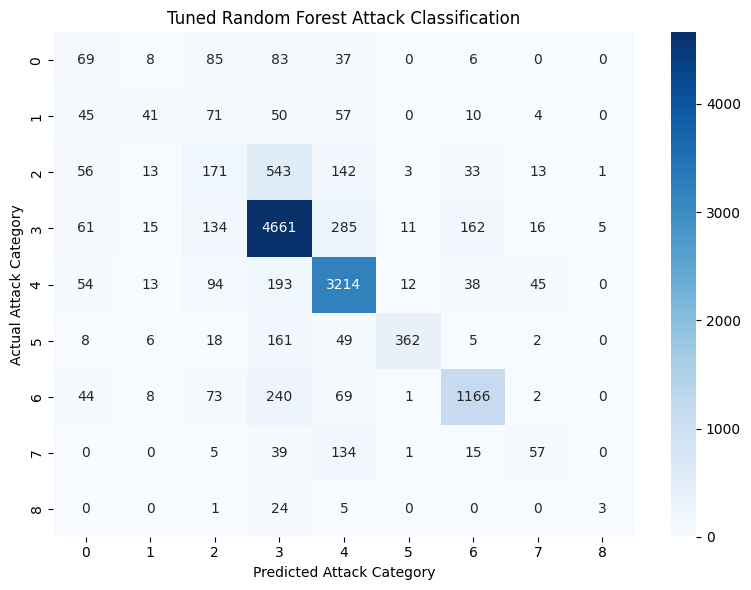

In [23]:
attack_cm = confusion_matrix(
    y_attack_test,
    attack_tuned_prediction
)
plt.figure(figsize=(8, 6))
sns.heatmap(
    attack_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Random Forest Attack Classification")
plt.xlabel("Predicted Attack Category")
plt.ylabel("Actual Attack Category")
plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Attack Classification Report

In [25]:
print(
    classification_report(
        y_attack_test,
        attack_tuned_prediction,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.20      0.24      0.22       288
           1       0.39      0.15      0.21       278
           2       0.26      0.18      0.21       975
           3       0.78      0.87      0.82      5350
           4       0.81      0.88      0.84      3663
           5       0.93      0.59      0.72       611
           7       0.81      0.73      0.77      1603
           8       0.41      0.23      0.29       251
           9       0.33      0.09      0.14        33

    accuracy                           0.75     13052
   macro avg       0.55      0.44      0.47     13052
weighted avg       0.73      0.75      0.73     13052



## Save Optimized Attack Classification Model

In [26]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_attack_rf,
    "../models/cybershield_tuned_attack_classifier.pkl"
)

print("Optimized attack classification model saved successfully.")

Optimized attack classification model saved successfully.


## Detection ROC Curve

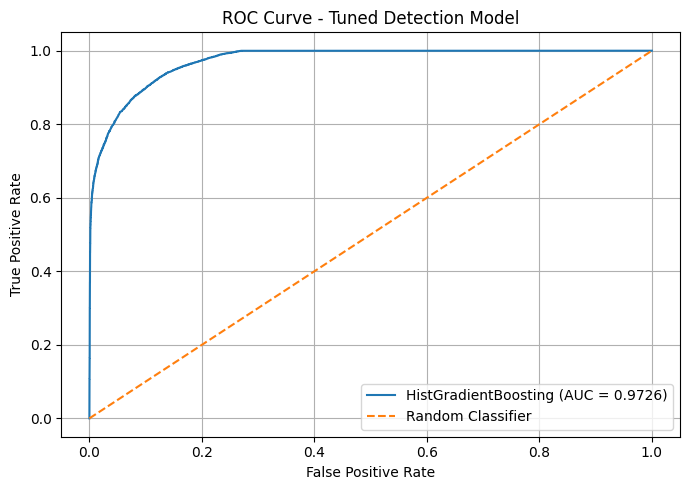

ROC-AUC Score: 0.9726110971512034


In [27]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, _ = roc_curve(
    y_test,
    attack_probabilities
)
roc_auc = roc_auc_score(
    y_test,
    attack_probabilities
)
plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"HistGradientBoosting (AUC = {roc_auc:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Detection Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("ROC-AUC Score:", roc_auc)

## Precision-Recall Curve

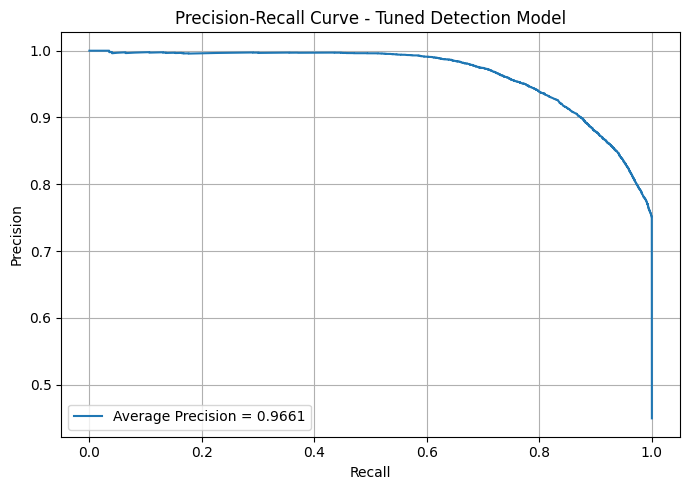

Average Precision: 0.9661338191128208


In [28]:
from sklearn.metrics import precision_recall_curve, average_precision_score
precision_values, recall_values, _ = precision_recall_curve(
    y_test,
    attack_probabilities
)
average_precision = average_precision_score(
    y_test,
    attack_probabilities
)
plt.figure(figsize=(7, 5))
plt.plot(
    recall_values,
    precision_values,
    label=f"Average Precision = {average_precision:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Tuned Detection Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Average Precision:", average_precision)

## Hyperparameter Tuning Summary

In [29]:
tuning_summary = pd.DataFrame({
    "Model": [
        "HistGradientBoosting Detection",
        "Random Forest Attack Classification"
    ],
    "Best Parameters": [
        str(hgb_search.best_params_),
        str(attack_search.best_params_)
    ],
    "Purpose": [
        "Detect Normal vs Attack traffic",
        "Identify the type of detected attack"
    ]
})

tuning_summary

,Model,Best Parameters,Purpose
0,HistGradientBoosting Detection,"{'min_samples_leaf': 20, 'max_leaf_nodes': 63,...",Detect Normal vs Attack traffic
1,Random Forest Attack Classification,"{'n_estimators': 100, 'min_samples_split': 5, ...",Identify the type of detected attack


## Final Protection-Oriented Model Configuration

In [30]:
print("CyberShield Final Model Configuration")
print("--------------------------------------")

print("Detection Model:")
print("HistGradientBoosting")

print("\nDetection Threshold:")
print(final_detection_threshold)

print("\nAttack Classification Model:")
print("Random Forest")

print("\nDetection Recall:")
print(tuned_recall)

print("Detection F1 Score:")
print(tuned_f1)

print("\nFalse Negatives at Default Threshold:")
print(default_fn)

print("False Negatives at Protection Threshold:")
print(protection_fn)

CyberShield Final Model Configuration
--------------------------------------
Detection Model:
HistGradientBoosting

Detection Threshold:
0.3

Attack Classification Model:
Random Forest

Detection Recall:
0.895341710082746
Detection F1 Score:
0.8883989660939638

False Negatives at Default Threshold:
1366
False Negatives at Protection Threshold:
385


## Save Final Optimized Models

In [31]:
joblib.dump(
    final_detection_model,
    "../models/cybershield_tuned_detection_model.pkl"
)

joblib.dump(
    best_attack_rf,
    "../models/cybershield_tuned_attack_classifier.pkl"
)

joblib.dump(
    final_detection_threshold,
    "../models/protection_threshold.pkl"
)

print("All optimized models and protection threshold saved successfully.")

All optimized models and protection threshold saved successfully.
